# Board Game Geek

## Scrapowanie danych

In [4]:
from scraper import Scraper
scraper = Scraper()

In [2]:
scraper.get_games(games=100)

100%|██████████| 100/100 [13:47<00:00,  8.27s/it]


In [2]:
del scraper

## Analiza danych

In [31]:
from matplotlib import pyplot as plt
import matplotlib as mpl
import numpy as np
from scraper import read_games

# plot style
mpl.rcParams['font.family'] = 'sans-serif'
mpl.rcParams['font.serif'] = ['Roboto', 'DejaVu Sans', 'Arial']
mpl.rcParams['font.size'] = 12
mpl.rcParams['axes.spines.top'] = False
mpl.rcParams['axes.spines.right'] = False
mpl.rcParams['axes.titlesize'] = 16
mpl.rcParams['axes.titlepad'] = 4
mpl.rcParams['axes.titleweight'] = 400

# dark mode
mpl.rcParams['figure.facecolor'] = '#1e1e1e'
mpl.rcParams['axes.facecolor'] = '#1e1e1e'
mpl.rcParams['axes.edgecolor'] = 'grey'
mpl.rcParams['axes.labelcolor'] = 'white'
mpl.rcParams['axes.titlecolor'] = 'white'
mpl.rcParams['xtick.color'] = 'white'
mpl.rcParams['ytick.color'] = 'white'
mpl.rcParams['text.color'] = 'white'

# dpi and figsize
mpl.rcParams['figure.dpi'] = 100
mpl.rcParams['figure.figsize'] = (8, 6)
%matplotlib inline

df = read_games()
df.shape

(10000, 36)

## Przygotowanie danych

In [32]:
# Usuwamy kolumnę `description` ponieważ nie wykorzystujemy jej w analizie
df = df.drop(columns=['description'])

# Usuwamy wiersze z brakującymi danymi
df = df.dropna()

# Konwertujemy zmienne na odpowiednie typy danych
cols_float = ['complexity', 'avg_rating', 'std_rating']
cols_int = ['year', 'min_players', 'max_players', 'min_play_time', 'max_play_time',
            'min_age', 'ratings', 'ratings_1', 'ratings_2', 'ratings_3', 'ratings_4',
            'ratings_5', 'ratings_6', 'ratings_7', 'ratings_8', 'ratings_9',
            'ratings_10', 'comments', 'fans', 'page_views', 'plays', 'plays_month',
            'owners', 'prev_owned', 'for_trade', 'want_in_trade', 'wishlist']
cols_list = ['alternate_names', 'designers', 'artists', 'publishers']
df[cols_float] = df[cols_float].astype(np.float32)
df[cols_int] = df[cols_int].astype(np.int32)
df[cols_list] = df[cols_list].map(lambda x: [i.strip(',') for i in x])

## Analiza eksploracyjna

In [50]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
year,9721.0,2006.226006,120.418038,-3500.000,2008.000,2015.000,2019.000,2.025000e+03
min_players,9721.0,1.886329,0.723886,1.000,1.000,2.000,2.000,9.000000e+00
max_players,9721.0,5.696122,8.809322,1.000,4.000,4.000,6.000,1.000000e+02
min_play_time,9721.0,55.078696,89.025827,1.000,30.000,45.000,60.000,5.400000e+03
max_play_time,9721.0,84.062751,239.605917,1.000,30.000,60.000,90.000,1.200000e+04
min_age,9721.0,10.890649,2.582124,2.000,8.000,12.000,13.000,2.100000e+01
complexity,9721.0,2.241834,0.799187,1.000,1.630,2.170,2.770,4.860000e+00
ratings,9721.0,2701.965950,6748.383615,324.000,505.000,896.000,2075.000,1.311550e+05
avg_rating,9721.0,6.967939,0.797025,2.747,6.467,6.985,7.522,9.387000e+00
std_rating,9721.0,1.399167,0.204331,0.950,1.260,1.370,1.510,4.030000e+00


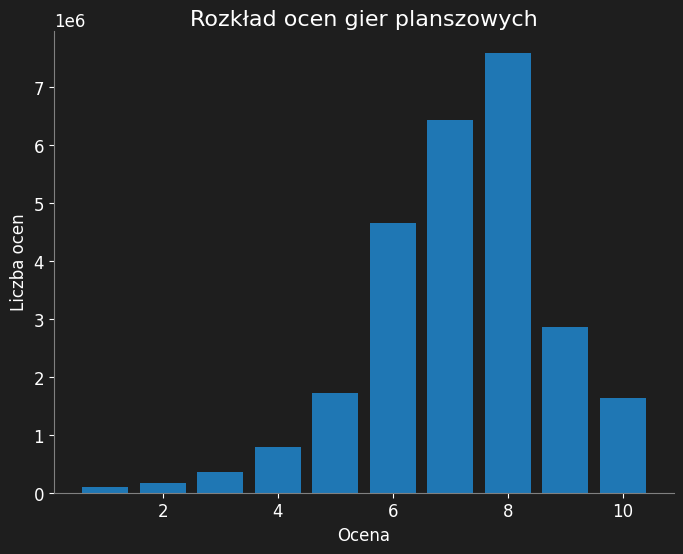

In [35]:
# Rozkład ocen
ratings = [f'ratings_{i}' for i in range(1, 11)]
ratings = df[ratings].sum()
ratings / ratings.sum()

plt.bar(list(range(1, 11)), ratings)
plt.xlabel('Ocena')
plt.ylabel('Liczba ocen')
plt.title('Rozkład ocen gier planszowych')
plt.show()

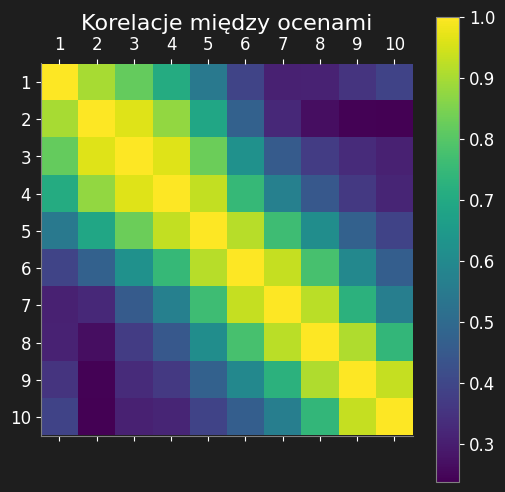

In [36]:
# Korelacje między ocenami
corr = df[ratings.index].corr()
plt.matshow(corr)
plt.xticks(range(len(ratings)), range(1, 11))
plt.yticks(range(len(ratings)), range(1, 11))
plt.colorbar()
plt.title('Korelacje między ocenami')
plt.show()

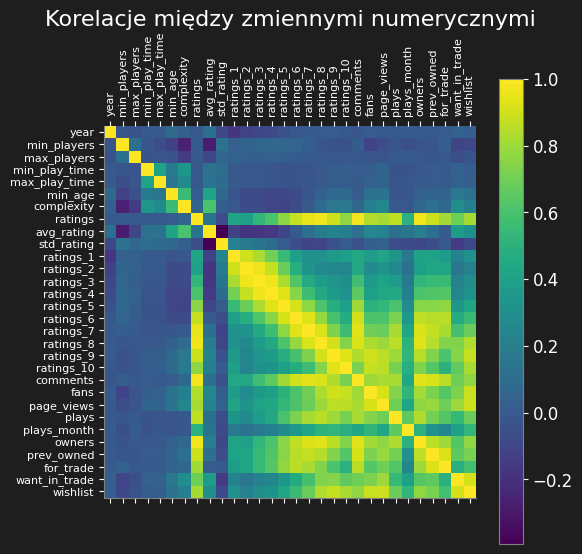

In [37]:
# Korelacje między zmiennymi numerycznymi
corr = df.select_dtypes(include='number').corr()
plt.matshow(corr)
plt.xticks(range(len(corr)), corr.columns)
plt.yticks(range(len(corr)), corr.columns)
plt.colorbar()
plt.title('Korelacje między zmiennymi numerycznymi')
plt.xticks(rotation=90)
plt.xticks(fontsize=8)
plt.yticks(fontsize=8)
plt.show()

MSE: 0.27296845158017247


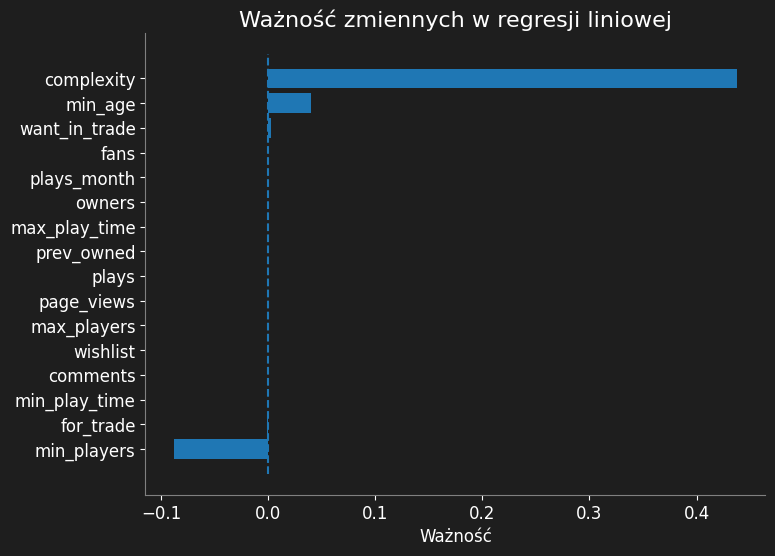

In [38]:
# Regresja liniowa
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

columns = ['min_players', 'max_players', 'min_play_time', 'max_play_time', 'min_age', 'complexity',
           'comments', 'fans', 'page_views', 'plays', 'plays_month', 'owners', 'prev_owned',
           'for_trade', 'want_in_trade', 'wishlist', 'avg_rating', 'std_rating']
X = df[['min_players', 'max_players', 'min_play_time', 'max_play_time', 'min_age', 'complexity',
             'comments', 'fans', 'page_views', 'plays', 'plays_month', 'owners', 'prev_owned',
             'for_trade', 'want_in_trade', 'wishlist']]
y = df['avg_rating'] # or 'std_rating'
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=314)

model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
mean_squared_error(y_test, y_pred)
print(f'MSE: {mean_squared_error(y_test, y_pred)}')

# Ważność zmiennych
importances = model.coef_
indices = np.argsort(importances)
plt.barh(range(X.shape[1]), importances[indices])
plt.yticks(range(X.shape[1]), X.columns[indices])
plt.xlabel('Ważność')
plt.vlines(0, -1, X.shape[1], linestyles='dashed')
plt.title('Ważność zmiennych w regresji liniowej')
plt.show()

In [39]:
# Model Gradient Boosting
from sklearn.ensemble import GradientBoostingRegressor

model = GradientBoostingRegressor()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
mean_squared_error(y_test, y_pred)
print(f'MSE: {mean_squared_error(y_test, y_pred)}')

MSE: 0.12007200805292184


In [40]:
# Sieć neuronowa
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor

scaler = StandardScaler()
scaler.fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = MLPRegressor(hidden_layer_sizes=(500, 32), max_iter=1000)
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)
mean_squared_error(y_test, y_pred)
print(f'MSE: {mean_squared_error(y_test, y_pred)}')

MSE: 0.1360165565726513


In [45]:
from keras.models import Sequential
from keras.layers import Dense, Dropout

model = Sequential([
    Dense(160, input_dim=X_train_scaled.shape[1], activation='relu'),
    Dropout(0.25),
    Dense(32, activation='relu'),
    Dense(1)
])
model.compile(loss='mean_squared_error', optimizer='adam')
history = model.fit(
    X_train_scaled, y_train,
    validation_data=(X_test_scaled, y_test),
    epochs=150, batch_size=32
)
y_pred = model.predict(X_test_scaled)
mean_squared_error(y_test, y_pred)

Epoch 1/150
243/243 [==============================] - 1s 2ms/step - loss: 8.5094 - val_loss: 1.4651
Epoch 2/150
243/243 [==============================] - 0s 2ms/step - loss: 1.4793 - val_loss: 0.6513
Epoch 3/150
243/243 [==============================] - 0s 1ms/step - loss: 0.9220 - val_loss: 0.4523
Epoch 4/150
243/243 [==============================] - 0s 2ms/step - loss: 0.6840 - val_loss: 0.3331
Epoch 5/150
243/243 [==============================] - 0s 1ms/step - loss: 0.5782 - val_loss: 0.3136
Epoch 6/150
243/243 [==============================] - 0s 2ms/step - loss: 0.5064 - val_loss: 0.2394
Epoch 7/150
243/243 [==============================] - 0s 2ms/step - loss: 0.4382 - val_loss: 0.2209
Epoch 8/150
243/243 [==============================] - 0s 2ms/step - loss: 0.4411 - val_loss: 0.2208
Epoch 9/150
243/243 [==============================] - 0s 2ms/step - loss: 0.4217 - val_loss: 0.2064
Epoch 10/150
243/243 [==============================] - 0s 1ms/step - loss: 0.3941 - val_lo

0.108433545

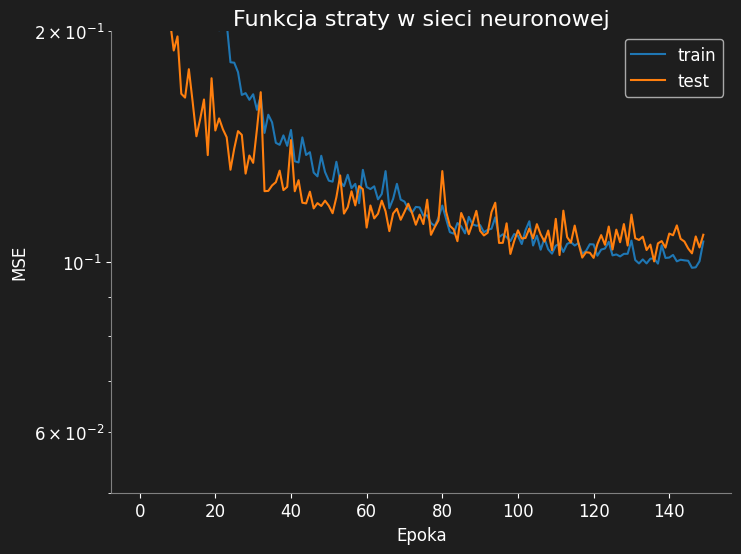

In [46]:
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='test')
plt.xlabel('Epoka')
plt.ylabel('MSE')
plt.yscale('log')
plt.ylim(0.05, 0.2)
plt.legend()
plt.title('Funkcja straty w sieci neuronowej')
plt.show()

In [47]:
mean_squared_error(y_test, y_pred)

0.108433545

In [48]:
min(history.history['val_loss'])

0.10008539259433746

MSE: 0.028419745077672955


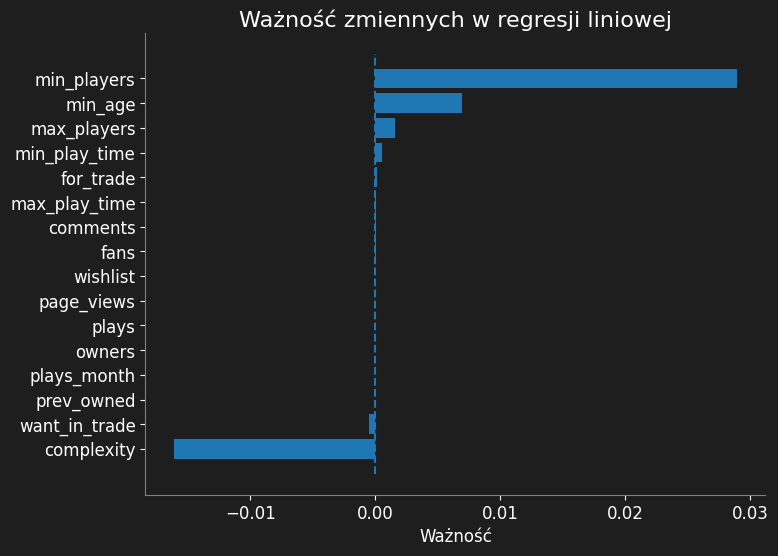

In [46]:
# Regresja dla odchylenia standardowego
X = dataset[['min_players', 'max_players', 'min_play_time', 'max_play_time', 'min_age', 'complexity',
             'comments', 'fans', 'page_views', 'plays', 'plays_month', 'owners', 'prev_owned',
             'for_trade', 'want_in_trade', 'wishlist']]
y = dataset['std_rating']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
mean_squared_error(y_test, y_pred)
print(f'MSE: {mean_squared_error(y_test, y_pred)}')

# Ważność zmiennych
importances = model.coef_
indices = np.argsort(importances)
plt.barh(range(X.shape[1]), importances[indices])
plt.yticks(range(X.shape[1]), X.columns[indices])
plt.xlabel('Ważność')
plt.vlines(0, -1, X.shape[1], linestyles='dashed')
plt.title('Ważność zmiennych w regresji liniowej')
plt.show()

In [47]:
# Model Gradient Boosting
from sklearn.ensemble import GradientBoostingRegressor

model = GradientBoostingRegressor()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
mean_squared_error(y_test, y_pred)
print(f'MSE: {mean_squared_error(y_test, y_pred)}')

MSE: 0.017558787720732112


In [90]:

# Sprawdzenie brakujących wartości
display(df.isnull().sum())


name                 0
year                 7
description        543
min_players          2
max_players          4
min_play_time       28
max_play_time       28
min_age             44
complexity           0
alternate_names      0
designers            0
artists              0
publishers           0
ratings              0
avg_rating           0
std_rating           0
ratings_1            0
ratings_2            0
ratings_3            0
ratings_4            0
ratings_5            0
ratings_6            0
ratings_7            0
ratings_8            0
ratings_9            0
ratings_10           0
comments             0
fans                 0
page_views           0
plays                0
plays_month          0
owners               0
prev_owned           0
for_trade            0
want_in_trade        0
wishlist             0
dtype: int64

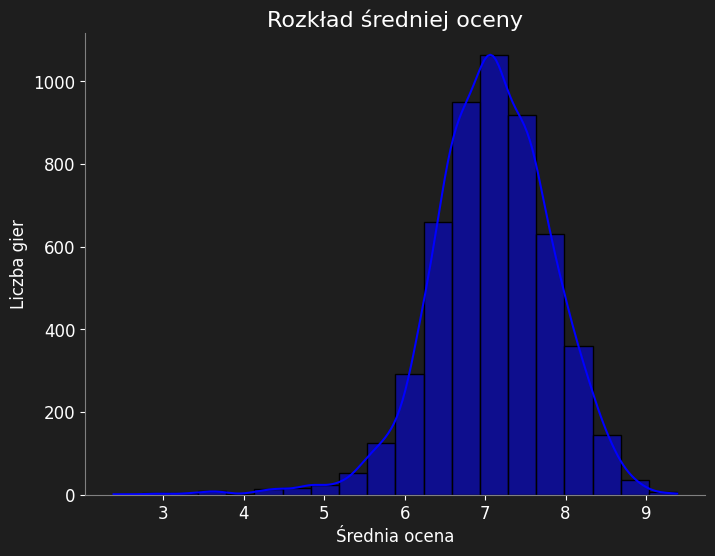

In [91]:

# Analiza korelacji między średnią oceną (avg_rating) a innymi cechami
# correlation_matrix = df.corr()
# sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm")
# plt.title("Macierz korelacji")
# plt.show()

# Analiza rozkładu średniej oceny
sns.histplot(df['avg_rating'], kde=True, bins=20, color='blue')
plt.title("Rozkład średniej oceny")
plt.xlabel("Średnia ocena")
plt.ylabel("Liczba gier")
plt.show()


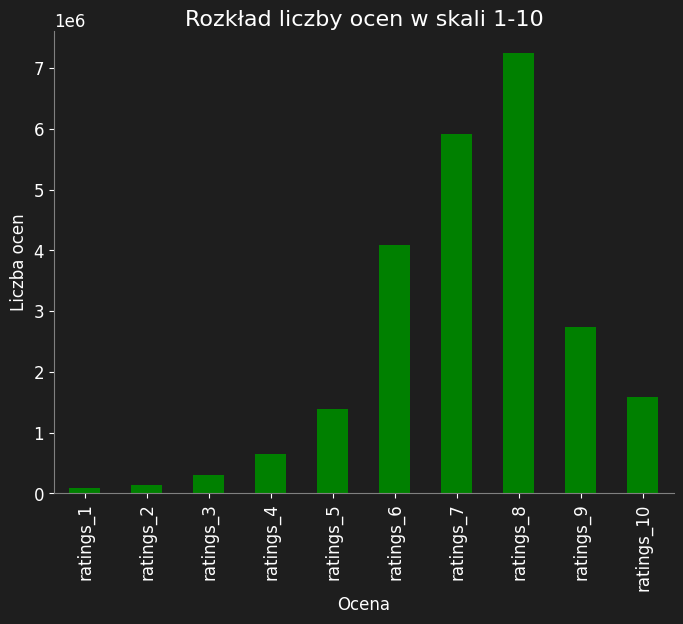

In [92]:

# Analiza rozkładów ocen (ratings_1 do ratings_10)
ratings_columns = [f'ratings_{i}' for i in range(1, 11)]
df[ratings_columns].sum().plot(kind='bar', color='green')
plt.title("Rozkład liczby ocen w skali 1-10")
plt.xlabel("Ocena")
plt.ylabel("Liczba ocen")
plt.show()


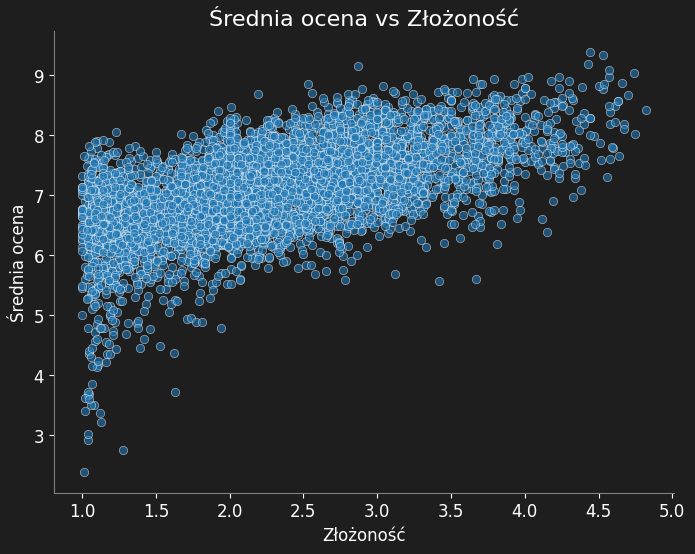

In [93]:

# Analiza złożoności (complexity) w stosunku do średniej oceny
sns.scatterplot(x=df['complexity'], y=df['avg_rating'], alpha=0.6)
plt.title("Średnia ocena vs Złożoność")
plt.xlabel("Złożoność")
plt.ylabel("Średnia ocena")
plt.show()


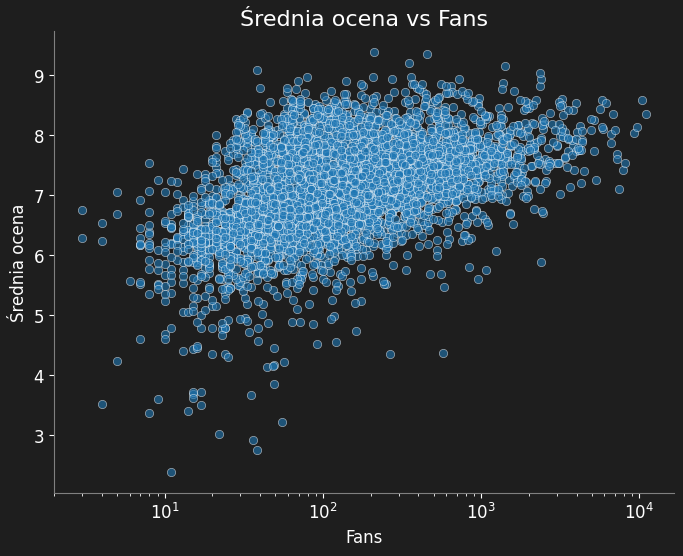

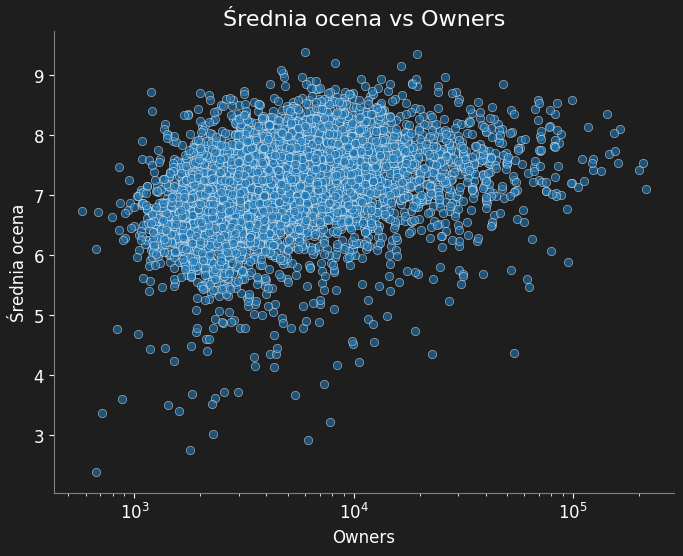

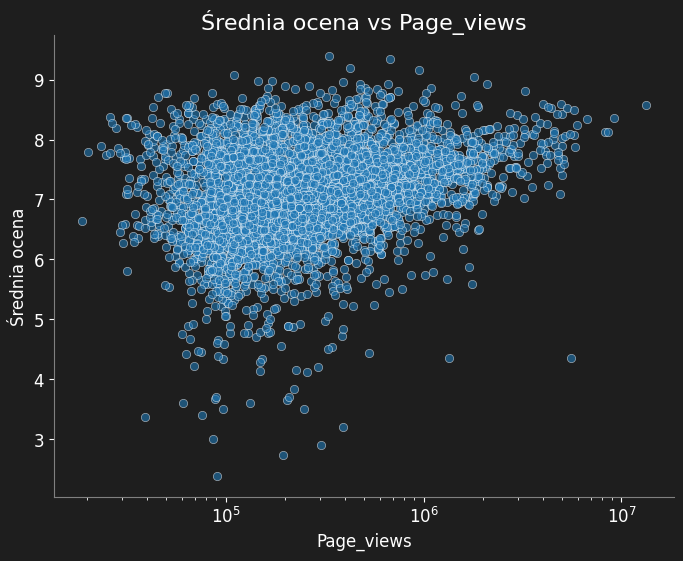

In [94]:

# Analiza popularności a średnia ocena
popularity_columns = ['fans', 'owners', 'page_views']
for col in popularity_columns:
    sns.scatterplot(x=df[col], y=df['avg_rating'], alpha=0.6)
    plt.title(f"Średnia ocena vs {col.capitalize()}")
    plt.xlabel(col.capitalize())
    plt.ylabel("Średnia ocena")
    plt.xscale('log')
    plt.show()


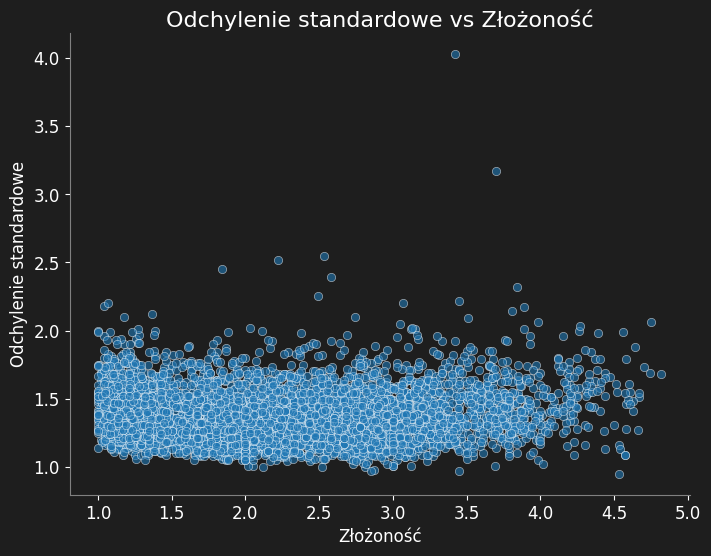

In [95]:

# Analiza odchylenia standardowego (std_rating) w stosunku do złożoności
sns.scatterplot(x=df['complexity'], y=df['std_rating'], alpha=0.6)
plt.title("Odchylenie standardowe vs Złożoność")
plt.xlabel("Złożoność")
plt.ylabel("Odchylenie standardowe")
plt.show()


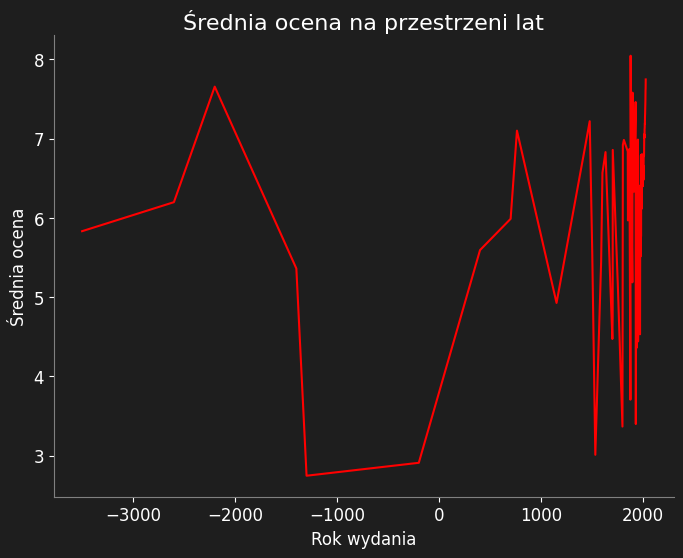

In [96]:

# Analiza średniej oceny w zależności od roku wydania
df.groupby('year')['avg_rating'].mean().plot(kind='line', color='red')
plt.title("Średnia ocena na przestrzeni lat")
plt.xlabel("Rok wydania")
plt.ylabel("Średnia ocena")
plt.show()


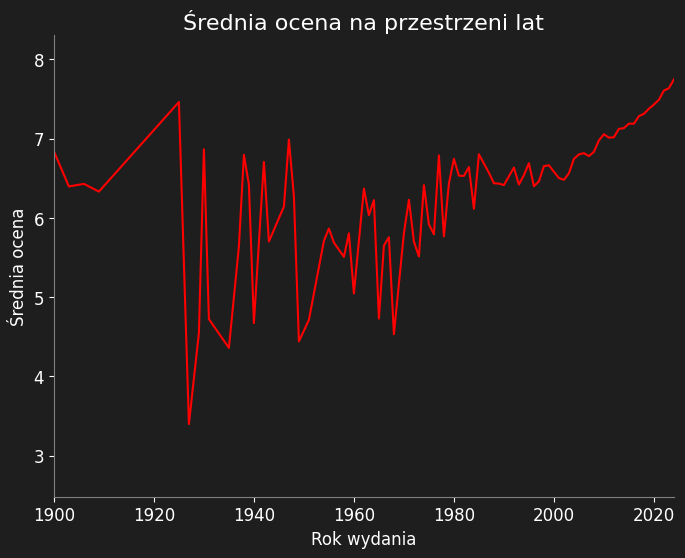

In [97]:

# Analiza średniej oceny w zależności od roku wydania
df.groupby('year')['avg_rating'].mean().plot(kind='line', color='red')
plt.title("Średnia ocena na przestrzeni lat")
plt.xlabel("Rok wydania")
plt.ylabel("Średnia ocena")
plt.xlim(1900, 2024)
plt.show()
